Found 160000 images belonging to 2 classes.
Found 22598 images belonging to 2 classes.
58892288/58889256 [==============================] - 0s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 2, 2, 512)         14714688  
_________________________________________________________________
dropout (Dropout)            (None, 2, 2, 512)         0         
_________________________________________________________________
conv2d (Conv2D)              (None, 2, 2, 512)         2359808   
_________________________________________________________________
batch_normalization (BatchNo (None, 2, 2, 512)         2048      
_________________________________________________________________
dropout_1 (Dropout)          (None, 2, 2, 512)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 

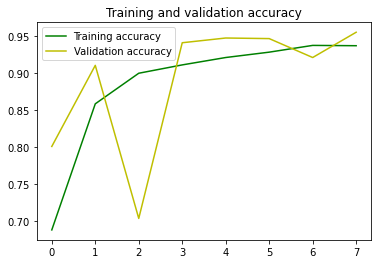

<Figure size 432x288 with 0 Axes>

[0.]
This is a male
[1.]
This is a male


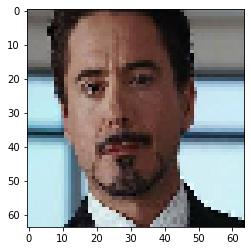

In [3]:
import os
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential,load_model,save_model
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from keras.layers import BatchNormalization
from keras.optimizers import Adam

train_datagen = ImageDataGenerator(rescale = 1./255,
      rotation_range=25,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')


batch_size = 64
target_size = (64, 64)
input_shape=(64, 64, 3)
seed=1337
adam = 0.001
fre= -20
FC = 2048
E = 1
patience = 3
verbose = 1
factor = 0.50
min_lr = 0.0001
steps_per_epoch=256
validation_steps=256
epochs=8

test_datagen = ImageDataGenerator( rescale = 1.0/255)

train_generator = train_datagen.flow_from_directory('../input/gender-dataset/Dataset/Train',
                                                    batch_size =batch_size ,
                                                    class_mode = 'binary',
                                                    seed=seed,
                                                    target_size = target_size )     

validation_generator =  test_datagen.flow_from_directory( '../input/gender-dataset/Dataset/Validation',
                                                          batch_size  = batch_size,
                                                          class_mode  = 'binary',
                                                          seed=seed,
                                                          target_size = target_size)

base_model = tf.keras.applications.VGG16(input_shape=input_shape,include_top=False,weights="imagenet")

# Freezing Layers

for layer in base_model.layers[:fre]:
    layer.trainable=False

# Building Model
model=Sequential()
model.add(base_model)
model.add(layers.Dropout(.2))

model.add(Conv2D(512, (3, 3),strides=(1,1), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.Dropout(.1))
model.add(Conv2D(128, (3, 3),strides=(1,1), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.Dropout(.1))
model.add(Conv2D(384, (3, 3),strides=(1,1), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.Dropout(.1))
model.add(Conv2D(384, (3, 3),strides=(1,1), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(layers.Dropout(.1))
model.add(Conv2D(500, (3, 3),strides=(1,1), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,strides=(2,2), padding='same'))



# Add new layers
model.add(Flatten())
model.add(Dense(FC , activation='relu'))
model.add(layers.Dropout(.2))
model.add(Dense(FC , activation='relu'))
model.add(layers.Dropout(.2))
model.add(Dense(FC, activation='relu'))
model.add(layers.Dropout(.2))
model.add(Dense(E, activation='sigmoid'))

model.summary()


model.compile(optimizer=Adam(adam),
              loss='binary_crossentropy'
              ,metrics=['accuracy'])

from tensorflow.keras.utils import plot_model
plot_model(model,show_shapes=True, show_layer_names=True, rankdir='TB', expand_nested=True)

lrd = ReduceLROnPlateau(monitor = 'val_loss',
                        patience = patience,
                        verbose = verbose ,
                        factor = factor,
                        min_lr = min_lr)

# mcp = ModelCheckpoint('model.h5')
mcp = ModelCheckpoint('gender_classification_model.h5', save_best_only=True)
es = EarlyStopping(verbose=verbose, patience=patience)

%time
hist = model.fit_generator(generator=train_generator,
                           validation_data=validation_generator,
                           steps_per_epoch=steps_per_epoch,
                           validation_steps=validation_steps,
                           epochs=model.save('/kaggle/working/gender_classification_model.h5'),
                           callbacks=[lrd, mcp, es])

model.save('/kaggle/working/gender_classification_model.h5')

import matplotlib.pyplot as plt
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
loss = hist.history['loss']
val_loss = hist.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'g', label='Training accuracy')
plt.plot(epochs, val_acc, 'y', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()
plt.show()

Prediction confidence: [0.9998271]
The predicted gender is: Male


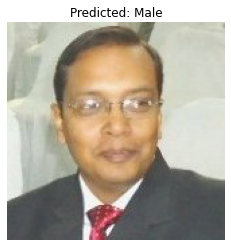

In [10]:
# Import necessary libraries
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Step 1: Load the Saved Model
model = load_model('/kaggle/working/gender_classification_model.h5')

# Step 2: Function to Load and Preprocess Image
def load_and_preprocess_image(image_path, target_size=(64, 64)):
    # Load image with the target size
    img = image.load_img(image_path, target_size=target_size)
    # Convert image to array
    img_array = image.img_to_array(img)
    # Expand dimensions to match model's input shape
    img_array = np.expand_dims(img_array, axis=0)
    # Normalize the image data
    img_array /= 255.0
    return img_array

# Step 3: Path to a Sample Image
# Replace the path with your sample image path
sample_image_path = '../input/testdata/profile_prashant.jpeg'  # Example image path

# Preprocess the sample image
sample_image = load_and_preprocess_image(sample_image_path)

# Step 4: Make a Prediction
prediction = model.predict(sample_image)

# Display the prediction
print("Prediction confidence:", prediction[0])

# Determine the predicted gender based on the threshold
predicted_gender = "Male" if prediction[0] > 0.5 else "Female"
print(f"The predicted gender is: {predicted_gender}")

# Optionally, display the image with the prediction
img = image.load_img(sample_image_path)
plt.imshow(img)
plt.title(f"Predicted: {predicted_gender}")
plt.axis('off')
plt.show()
